In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from scipy.stats import chi2_contingency, pointbiserialr
import os

from sklearn.preprocessing import StandardScaler,StandardScaler, OrdinalEncoder
from sklearn.model_selection import train_test_split

import missingno as msno
from sklearn.utils import resample

from sklearn.preprocessing import MinMaxScaler
from scipy.stats import skew
import missingno as msno

## Diabetics Analysis

### Extract the Diabetics patients and equal amount of non Diabetics


HadDiabetes Summary:
                Count  Percentage
has_diabetes                     
0.0           1216560       84.50
1.0            182062       12.65
NaN             41074        2.85


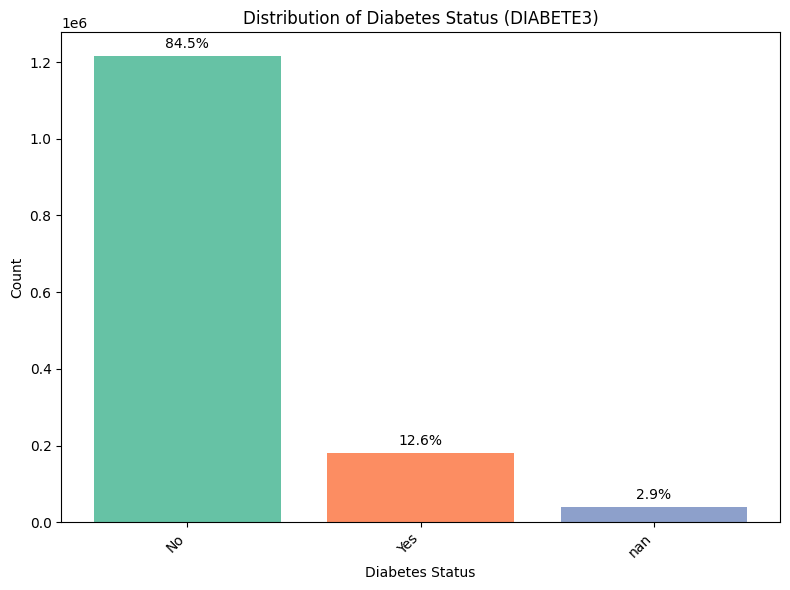

In [2]:
# Load the dataset
df = pd.read_csv('../data/processed/BRFSS_13.csv', low_memory=False)

target = "has_diabetes"

# Check if target exists
if target not in df.columns:
    raise KeyError(f"Target column '{target}' not found in dataset. Available columns: {list(df.columns)}")

# Value counts
value_counts = df[target].value_counts(dropna=False).sort_index()
value_percent = df[target].value_counts(normalize=True, dropna=False).sort_index() * 100

# Combine into summary DataFrame
target_summary = pd.DataFrame({
    "Count": value_counts,
    "Percentage": value_percent.round(2)
})

print("\nHadDiabetes Summary:")
print(target_summary)

# BAR PLOT (appropriate for categorical data) 
plt.figure(figsize=(8, 6))

# Define category labels based on BRFSS coding (adjust if your recoding differs)
labels = {
    0.0: 'No',
    1.0: 'Yes',
    float('nan'): 'Missing'
}

# Map index to labels
tick_labels = [labels.get(cat, str(cat)) for cat in value_counts.index]

# Plot
bars = plt.bar(tick_labels, value_counts.values, color=["#66c2a5", "#fc8d62", "#8da0cb", "#e78ac3", "#a6d854"])

# Add percentage labels on bars
for bar, pct in zip(bars, value_percent.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(value_counts) * 0.01,
             f'{pct:.1f}%', ha='center', va='bottom')

plt.title("Distribution of Diabetes Status (DIABETE3)")
plt.xlabel("Diabetes Status")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../results/had_diabetes_bar.png')
plt.show()

In [3]:
counts = df[target].value_counts()
proportions = df[target].value_counts(normalize=True) * 100

print("\nCounts:")
print(counts)
print("\nPercentages:")
print(proportions.round(2))

# Split Majority / Minority

df_majority = df[df[target] == 0.0]
df_minority = df[df[target] == 1.0]

print(f"\nMajority class size (0.0): {len(df_majority)}")
print(f"Minority class size (1.0): {len(df_minority)}")

# Downsample Majority

df_majority_downsampled = resample(
    df_majority,
    replace=False,             # no replacement
    n_samples=len(df_minority),# match minority size
    random_state=42
)

# Combine Balanced Dataset

df_balanced = pd.concat([df_majority_downsampled, df_minority])
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)  # shuffle

print(f"\n Balanced dataset created: {df_balanced.shape[0]} rows")

# Check New Distribution

balanced_counts = df_balanced[target].value_counts()
balanced_proportions = df_balanced[target].value_counts(normalize=True) * 100

print("\nBalanced Counts:")
print(balanced_counts)
print("\nBalanced Percentages:")
print(balanced_proportions.round(2))

# Save Balanced Dataset

output_path = '../data/processed/BRFSS_Diabetes_Balanced.csv'
os.makedirs(os.path.dirname(output_path), exist_ok=True)
df_balanced.to_csv(output_path, index=False)

print(f"\n Balanced dataset saved to: {output_path}")



Counts:
has_diabetes
0.0    1216560
1.0     182062
Name: count, dtype: int64

Percentages:
has_diabetes
0.0    86.98
1.0    13.02
Name: proportion, dtype: float64

Majority class size (0.0): 1216560
Minority class size (1.0): 182062

 Balanced dataset created: 364124 rows

Balanced Counts:
has_diabetes
0.0    182062
1.0    182062
Name: count, dtype: int64

Balanced Percentages:
has_diabetes
0.0    50.0
1.0    50.0
Name: proportion, dtype: float64

 Balanced dataset saved to: ../data/processed/BRFSS_Diabetes_Balanced.csv


### Remove Metadata like Date time, States

In [4]:
# Load CSV file 
df = pd.read_csv('../data/processed/BRFSS_Diabetes_Balanced.csv')

# Show dataset dimensions
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

# Show feature (column) names
print("\nFeature names (columns):")
print(df.columns.tolist())

# Show first 5 rows of the dataset
print("\nFirst 5 rows of the dataset:")
print(df.head())

# Show dataset info 
print("\nDataset Info:")
print(df.info())


Number of rows: 364124
Number of columns: 84

Feature names (columns):
['LSTBLDS3', '_MISVEGN', 'age_cat', 'had_cvd', 'takes_aspirin', 'general_health_cat', 'physical_health_bad', 'poor_health_days', 'has_activity_limitation', 'has_depression', 'has_asthma', 'has_arthritis', 'general_health_risk', 'mental_health_bad', 'has_high_bp', 'has_high_cholesterol', 'has_kidney_disease', 'chronic_conditions_standard', 'has_diabetes', 'tested_for_diabetes', 'high_bp_risk', 'blood_sugar_checks', 'had_cholesterol_check', 'recent_cholesterol_check', 'no_cholesterol_check_5yr', 'cholesterol_checked_5yr', 'cholesterol_screening_score', 'had_pneumonia_vaccine', 'pneumonia_vaccine_status', 'vaccine_score', 'BMI', 'has_cost_barrier', 'no_cost_barrier', 'care_access_score', 'uses_ecigarettes', 'meets_aerobic_guidelines', 'exercised_past_30d', 'meets_strength_guidelines', 'has_strength_training', 'total_exercise_freq', 'total_activity_duration', 'uses_exercise_equipment', 'fruit_servings_day', 'juice_servi

In [5]:
# Load cleaned dataset
df = pd.read_csv('../data/processed/BRFSS_Diabetes_Balanced.csv')

# Define columns to DROP (metadata, weights, admin, non-clinical)
metadata_cols = [
    # # Survey weights & design
    # 'SEQNO', 'MSCODE', '_STATE', '_PSU', '_STRWT', '_STSTR',
    # '_LLCPWT', '_RAWRAKE', '_WT2RAKE', '_CLLCPWT',
    
    # # Date/time
    # 'IDAY', 'IMONTH', 'IDATE', 'IYEAR', 'FMONTH', 'YEAR', 'YEAR.1',
    
    # # Interview/admin metadata
    # 'RCSGENDR', 'CPDEMO1', 'CSTATE', 'CTELENUM', 'CTELNUM1', 'DISPCODE',
    # 'QSTLANG', 'QSTVER', 'LANDLINE', 'CELLFON2', 'PVTRESD2', '_RFSEAT3', '_RFSEAT2',
    
    # # Household composition (not individual health)
    # 'NUMADULT', 'NUMHHOL2', 'NUMMEN', 'NUMWOMEN', 'CADULT',
    
    # # Other non-clinical
    # 'VETERAN3', 'MARITAL', 'RENTHOM1', 'SEATBELT', 'USEEQUIP', 'USENOW3',
    # 'CASTHDX2', 'CVDASPRN', 'IMFVPLAC', 'RCSRLTN2', '_CHLDCNT',
    # 'MAXVO2_', 'FC60_', 

    # # Add any other known non-medical columns here
    # '_VEGRESP', '_FRTRESP'

    '_MISVEGN', 'LSTBLDS3'

]

# Only keep columns that exist in your dataset
cols_to_drop = [col for col in metadata_cols if col in df.columns]
print(f"Found {len(cols_to_drop)} metadata/admin columns to drop.")

# Drop them
df_medical = df.drop(columns=cols_to_drop, errors='ignore')
print(f"Shape after dropping metadata: {df_medical.shape}")


# Final check
print(f"\n Final dataset shape: {df_medical.shape}")
print(f"Columns remaining: {df_medical.shape[1]}")

# Save
output_path = '../data/processed/BRFSS_Diabetes_MedicalOnly.csv'
df_medical.to_csv(output_path, index=False)
print(f"\n Medical-only dataset saved to: {output_path}")

Found 2 metadata/admin columns to drop.
Shape after dropping metadata: (364124, 82)

 Final dataset shape: (364124, 82)
Columns remaining: 82

 Medical-only dataset saved to: ../data/processed/BRFSS_Diabetes_MedicalOnly.csv


### Clean the Dataset

In [6]:

# Define the file path (Adjust this path if necessary in your environment)
FILE_PATH = '../data/processed/BRFSS_Diabetes_MedicalOnly.csv'

try:
    # Load the dataset
    df = pd.read_csv(FILE_PATH)
    print(f"Successfully loaded dataset from: {FILE_PATH}")
    print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")

except FileNotFoundError:
    print(f"Error: File not found at {FILE_PATH}. Please ensure the path is correct.")
except Exception as e:
    print(f"An error occurred during file loading: {e}")

Successfully loaded dataset from: ../data/processed/BRFSS_Diabetes_MedicalOnly.csv
Dataset shape: 364124 rows, 82 columns


In [7]:
total_rows = len(df)

# Calculate null counts and percentages
null_counts = df.isnull().sum()
null_percentages = (null_counts / total_rows) * 100

# Combine results into a DataFrame and filter for columns with missing data
missing_data_summary = pd.DataFrame({
    'Null Count': null_counts,
    'Null Percentage': null_percentages.round(2)
}).sort_values(by='Null Percentage', ascending=False)

# Filter out columns with 0 missing values for a cleaner report/plot
missing_data_summary = missing_data_summary[missing_data_summary['Null Count'] > 0]

print("=========================================================")
print("  MISSING VALUE ANALYSIS (Columns with > 0% NaNs)")
print("=========================================================")
print(missing_data_summary)

  MISSING VALUE ANALYSIS (Columns with > 0% NaNs)
                      Null Count  Null Percentage
recent_mammogram          351649            96.57
ever_pap_test             350880            96.36
ever_mammogram            350814            96.34
recent_pap_test           336939            92.53
usual_drinks_per_day      331938            91.16
...                          ...              ...
no_cost_barrier             1059             0.29
has_cost_barrier            1059             0.29
high_bp_risk                 970             0.27
skin_cancer                  902             0.25
other_cancer                 858             0.24

[69 rows x 2 columns]


C:\Users\hasit\AppData\Local\Temp\ipykernel_22388\1857694042.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


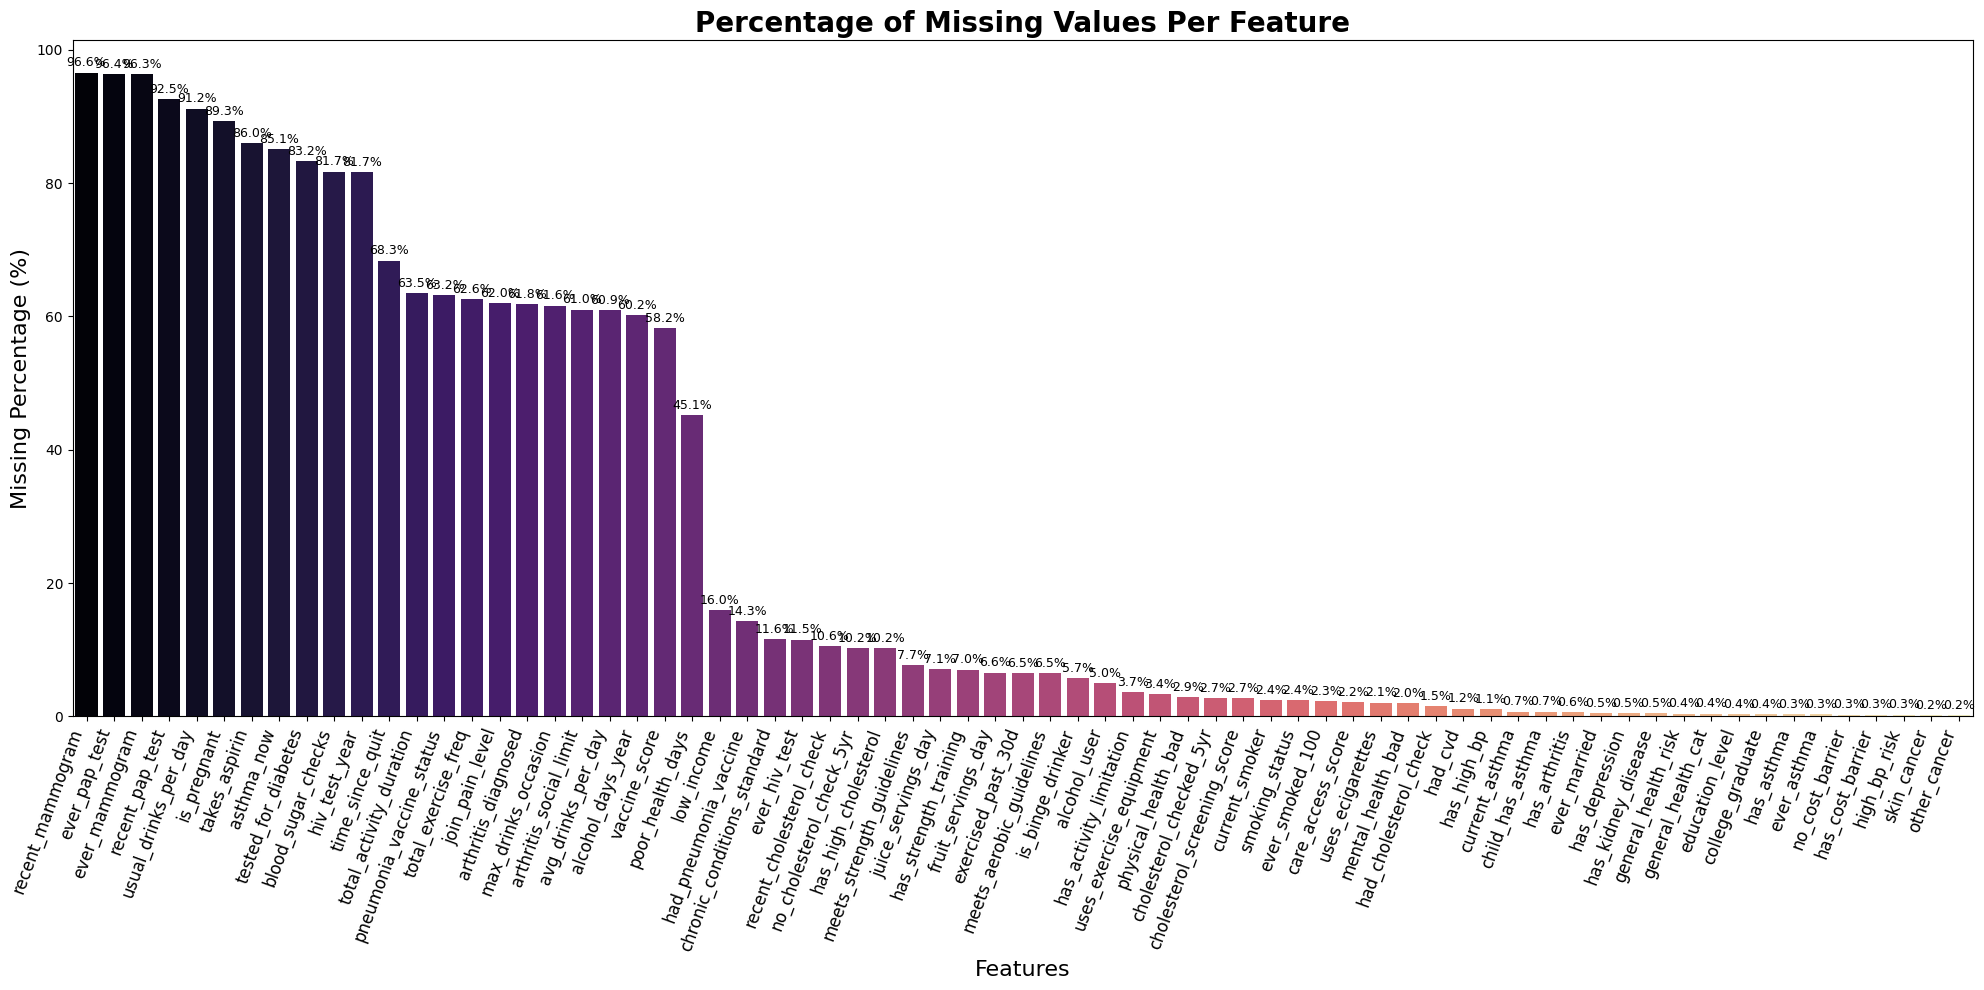


Features with > 40% Missing Data:
['recent_mammogram', 'ever_pap_test', 'ever_mammogram', 'recent_pap_test', 'usual_drinks_per_day', 'is_pregnant', 'takes_aspirin', 'asthma_now', 'tested_for_diabetes', 'blood_sugar_checks', 'hiv_test_year', 'time_since_quit', 'total_activity_duration', 'pneumonia_vaccine_status', 'total_exercise_freq', 'join_pain_level', 'arthritis_diagnosed', 'max_drinks_occasion', 'arthritis_social_limit', 'avg_drinks_per_day', 'alcohol_days_year', 'vaccine_score', 'poor_health_days']


In [8]:
if missing_data_summary.empty:
    print("No missing values found in the dataset.")
else:
    # Set figure size for better visibility
    plt.figure(figsize=(20, 10))
    
    # Create the bar plot using Seaborn
    ax = sns.barplot(
        x=missing_data_summary.index, 
        y='Null Percentage', 
        data=missing_data_summary, 
        palette='magma' # Using a different palette for visualization
    )
    
    # Add title and labels
    ax.set_title('Percentage of Missing Values Per Feature', fontsize=20, fontweight='bold')
    ax.set_ylabel('Missing Percentage (%)', fontsize=16)
    ax.set_xlabel('Features', fontsize=16)
    
    # Rotate x-axis labels for readability
    plt.xticks(rotation=70, ha='right', fontsize=12)
    
    # Add percentage labels above the bars
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
             ax.annotate(f'{height:.1f}%', 
                        (p.get_x() + p.get_width() / 2., height),
                        ha='center', 
                        va='center', 
                        xytext=(0, 7), 
                        textcoords='offset points',
                        fontsize=9)

    plt.tight_layout()
    plt.show()

    # Identifying features with > 40% missing data
    highly_missing = missing_data_summary[missing_data_summary['Null Percentage'] > 40].index.tolist()
    if highly_missing:
        print("\nFeatures with > 40% Missing Data:")
        print(highly_missing)


In [9]:
# Features with > 40% missing data (MNAR candidates)
mnar_candidates = missing_data_summary[missing_data_summary['Null Percentage'] > 40].index.tolist()

print(f"Applying Indicator + Impute 0 strategy to {len(mnar_candidates)} columns...")

for col in mnar_candidates:
    # 1. Create the indicator feature: 1 if NaN, 0 otherwise
    df[f'{col}_missing_indicator'] = df[col].isnull().astype(int)
    
    # 2. Impute the original column with 0 (since most are counts/frequencies, 0 is a plausible baseline)
    df[col] = df[col].fillna(0)

# Verify the missing indicators were created
print(f"Created {len(mnar_candidates)} new missing indicator columns.")


Applying Indicator + Impute 0 strategy to 23 columns...
Created 23 new missing indicator columns.


In [10]:
# Identify columns that still have NaNs (excluding the MNAR candidates already fixed)
remaining_missing_cols = df.columns[df.isnull().any()].tolist()

print(f"\nApplying Mode Imputation to {len(remaining_missing_cols)} remaining columns...")

for col in remaining_missing_cols:
    # Get the mode (most frequent value)
    mode_value = df[col].mode()[0]
    
    # Impute NaNs with the mode
    df[col] = df[col].fillna(mode_value)
    
    print(f"  - Imputed '{col}' with mode: {mode_value}")

print("\n--- Final Check ---")
print(f"Total NaNs remaining: {df.isnull().sum().sum()}")

# Save the fully imputed DataFrame
CLEANED_FILE_PATH = '../data/processed/BRFSS_Diabetes_Cleaned.csv'
df.to_csv(CLEANED_FILE_PATH, index=False)
print(f"Data correction complete and saved to: {CLEANED_FILE_PATH}")


Applying Mode Imputation to 46 remaining columns...
  - Imputed 'had_cvd' with mode: 0.0
  - Imputed 'general_health_cat' with mode: 1.0
  - Imputed 'physical_health_bad' with mode: 0.0
  - Imputed 'has_activity_limitation' with mode: 0.0
  - Imputed 'has_depression' with mode: 0.0
  - Imputed 'has_asthma' with mode: 0.0
  - Imputed 'has_arthritis' with mode: 0.0
  - Imputed 'general_health_risk' with mode: 1.0
  - Imputed 'mental_health_bad' with mode: 0.0
  - Imputed 'has_high_bp' with mode: 1.0
  - Imputed 'has_high_cholesterol' with mode: 1.0
  - Imputed 'has_kidney_disease' with mode: 0.0
  - Imputed 'chronic_conditions_standard' with mode: 2.0
  - Imputed 'high_bp_risk' with mode: 1.0
  - Imputed 'had_cholesterol_check' with mode: 1.0
  - Imputed 'recent_cholesterol_check' with mode: 1.0
  - Imputed 'no_cholesterol_check_5yr' with mode: 0.0
  - Imputed 'cholesterol_checked_5yr' with mode: 1.0
  - Imputed 'cholesterol_screening_score' with mode: 2.0
  - Imputed 'had_pneumonia_vac

In [11]:
df = pd.read_csv('../data/processed/BRFSS_Diabetes_Cleaned.csv')

# Show dataset dimensions
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

# Show feature (column) names
print("\nFeature names (columns):")
print(df.columns.tolist())

# Show first 5 rows of the dataset
print("\nFirst 5 rows of the dataset:")
print(df.head())

# Show dataset info 
print("\nDataset Info:")
print(df.info())


Number of rows: 364124
Number of columns: 105

Feature names (columns):
['age_cat', 'had_cvd', 'takes_aspirin', 'general_health_cat', 'physical_health_bad', 'poor_health_days', 'has_activity_limitation', 'has_depression', 'has_asthma', 'has_arthritis', 'general_health_risk', 'mental_health_bad', 'has_high_bp', 'has_high_cholesterol', 'has_kidney_disease', 'chronic_conditions_standard', 'has_diabetes', 'tested_for_diabetes', 'high_bp_risk', 'blood_sugar_checks', 'had_cholesterol_check', 'recent_cholesterol_check', 'no_cholesterol_check_5yr', 'cholesterol_checked_5yr', 'cholesterol_screening_score', 'had_pneumonia_vaccine', 'pneumonia_vaccine_status', 'vaccine_score', 'BMI', 'has_cost_barrier', 'no_cost_barrier', 'care_access_score', 'uses_ecigarettes', 'meets_aerobic_guidelines', 'exercised_past_30d', 'meets_strength_guidelines', 'has_strength_training', 'total_exercise_freq', 'total_activity_duration', 'uses_exercise_equipment', 'fruit_servings_day', 'juice_servings_day', 'total_fruit_

Total Numerical Features: 105
Total Categorical Features: 0


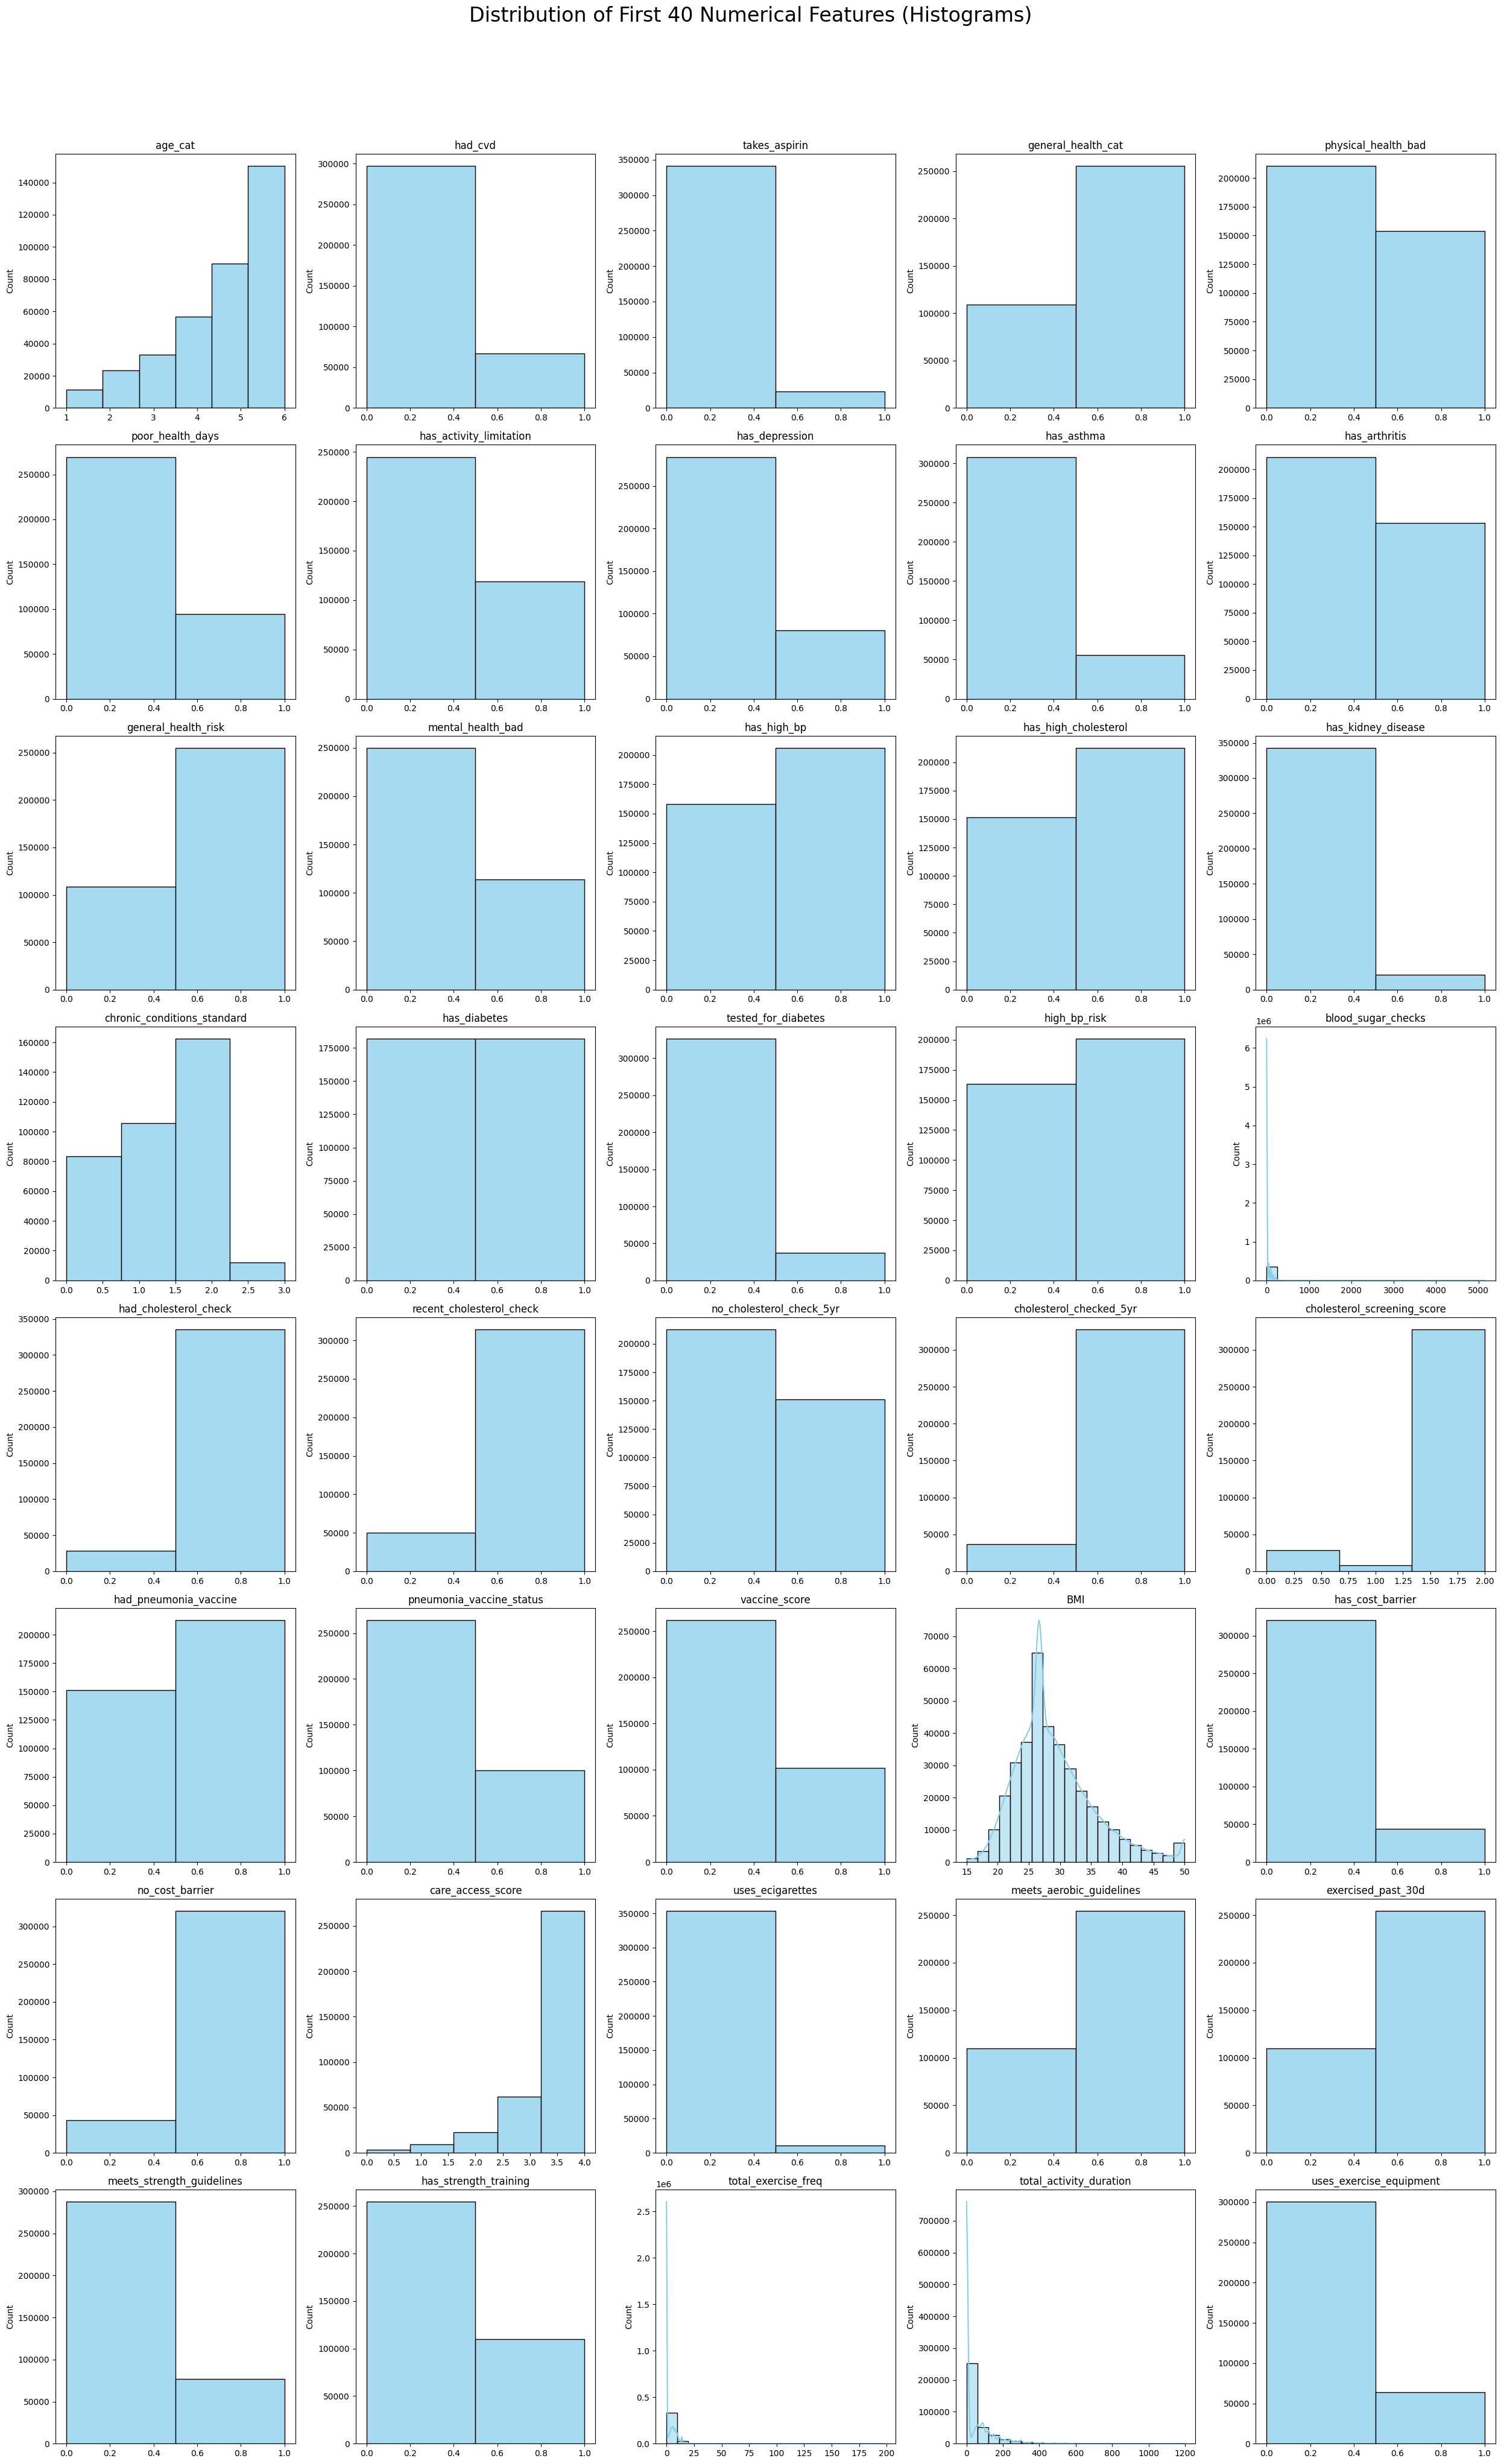


No categorical features (dtype 'object') remain for plotting.


In [ ]:

# Identify feature types after imputation
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"Total Numerical Features: {len(numerical_cols)}")
print(f"Total Categorical Features: {len(categorical_cols)}")

# Visualization for Numerical Features (Histograms)

# We only plot the first 40 numerical features for visual management, 
# as plotting all 70+ in one grid is too dense.
num_features_to_plot = min(len(numerical_cols), 40)
plot_cols_num = numerical_cols[:num_features_to_plot]

n_rows_num = (len(plot_cols_num) + 4) // 5 # Calculate rows for 5 columns per row
plt.figure(figsize=(25, 5 * n_rows_num))
plt.suptitle(f'Distribution of First {num_features_to_plot} Numerical Features (Histograms)', fontsize=24, y=1.02)

for i, col in enumerate(plot_cols_num):
    plt.subplot(n_rows_num, 5, i + 1)
    # Check if the feature is binary/discrete to ensure proper binning
    unique_values = df[col].nunique()
    if unique_values <= 50 and df[col].dtype in ['int64', 'float64']:
        # Treat as discrete/binary (use specific bins)
        sns.histplot(df[col], kde=False, bins=unique_values, color='skyblue')
    else:
        # Treat as continuous
        sns.histplot(df[col], kde=True, bins=20, color='skyblue')
        
    plt.title(col, fontsize=12)
    plt.xlabel('') 
    plt.ylabel('Count', fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()


# Visualization for Categorical Features (Count Plots)

if categorical_cols:
    n_cat = len(categorical_cols)
    plt.figure(figsize=(15, 5 * n_cat))
    plt.suptitle('Distribution of Categorical Features (Count Plots)', fontsize=24, y=1.02)

    for i, col in enumerate(categorical_cols):
        plt.subplot(n_cat, 1, i + 1)
        sns.countplot(y=col, data=df, order=df[col].value_counts().index, palette='viridis')
        plt.title(col, fontsize=16)
        plt.xlabel('Count', fontsize=12)
        plt.ylabel('', fontsize=12)
        plt.xticks(fontsize=10)
        plt.yticks(fontsize=10)

    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()
else:
    print("\nNo categorical features (dtype 'object') remain for plotting.")

## Total Time = 47.6S